# Adversarial Robustness Research Series

## Experiment 02f Defending Against Adversarial Attacks Input Transform

This notebook is part of a continuous AI security experimentation track.

- steps: 
  - Step 1  Environment setup
  - Step 2  Data prep/loading
  - Step 3  Training setup and helper functions
  - Step 4  Train the MNIST classifier
  - Step 5  Baseline evaluation
  - Step 6  Adversarial attacks
  - Step 7  Detector
  - Step 8  Input transformations
  - Step 9  Results
  - Step 10 Results Export
  - Step 11 Takeaways

Environment notes
Windows laptop CPU execution by default

In [1]:
import sys
import platform
print("exe", sys.executable)
print("ver", sys.version)
print("plat", platform.platform())


exe c:\Users\natyn\anaconda3\envs\ai-sec-research\python.exe
ver 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
plat Windows-10-10.0.26200-SP0


In [2]:
import os
import json
import time
import math
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import subprocess
import importlib.util

In [3]:
# Device selection
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)
print("Torch:", torch.__version__)

# CPU optimization
if device.type == "cpu":
    try:
        torch.set_num_threads(16)
        torch.set_num_interop_threads(16)
    except Exception as e:
        print("Thread config skipped:", repr(e))

    os.environ["OMP_NUM_THREADS"] = "16"
    os.environ["MKL_NUM_THREADS"] = "16"
    os.environ["KMP_BLOCKTIME"] = "1"
    os.environ["KMP_AFFINITY"] = "granularity=fine,compact,1,0"


Device: cpu
Torch: 2.10.0+cpu


## Part 1: Baseline ML pipeline

### Step 1: Dataset preparation

In [4]:
# MNIST normalization according to Pytorch documentation: https://pytorch.org/vision/stable/datasets.html#mnist
mnist_mean = 0.1307
mnist_std = 0.3081

transform = transforms.Compose([# transformations pipeline applied to the data
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,))
])
#loading the MNIST dataset to trai
trainset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
#test dataset to measure the results of the training
testset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

trainloader = DataLoader(trainset, batch_size=256, shuffle=True, num_workers=0, persistent_workers=False)
testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=0, persistent_workers=False)

images, labels = next(iter(trainloader))
print("Train size", len(trainset), "Test size", len(testset))
print("Batch", images.shape, labels.shape)


Train size 60000 Test size 10000
Batch torch.Size([256, 1, 28, 28]) torch.Size([256])


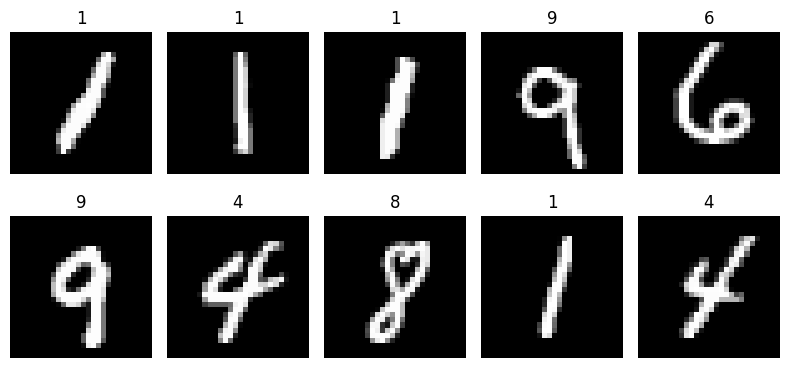

In [5]:
# Sample batch visualization
plt.figure(figsize=(8, 4))
for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    img = images[i].cpu() * mnist_std + mnist_mean
    ax.imshow(img.squeeze(0), cmap="gray")
    ax.set_title(int(labels[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()


### Step 2: Baseline MNIST model creation

Simple small CNN trained from scratch

In [6]:
class MNISTCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def create_model_and_optimizer(device, lr=1e-3):
    model = MNISTCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    return model, criterion, optimizer

model, criterion, optimizer = create_model_and_optimizer(device)

print(model)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))


MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Number of parameters: 421642


### Step 3: Training setup and helper functions
setup model, loss, optimizer, training parameters

In [7]:
def accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer, device, max_batches=None):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    batches = 0

    for batch_idx, (images, labels) in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        total_acc += accuracy_from_logits(logits, labels)#accuracy calculation for the batch
        batches += 1

    denom = max(batches, 1)
    return total_loss / denom, total_acc / denom

@torch.no_grad()
def evaluate_clean_accuracy(model, dataloader, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)


### Step 4: Verification model ok

In [8]:
model.eval()
images, labels = next(iter(trainloader))
images = images.to(device)
labels = labels.to(device)

logits = model(images)
loss = criterion(logits, labels)
acc = accuracy_from_logits(logits, labels)

print("Check OK")
print("Loss:", float(loss.item()))
print("Accuracy:", float(acc))


Check OK
Loss: 2.2982065677642822
Accuracy: 0.1640625


### Step 5: Train baseline model

In [9]:
#2 passes of training with 10 batches each to speed up the process for demonstration purposes
epochs = 2
max_batches_train = 10
max_batches_test = 10

history = {"epoch": [], "train_loss": [], "train_acc": [], "test_acc": []}#history dictionary to store the training history for visualization
# #training loop
# For each batch in the trainloader:
    #   1) send the images through the model
    #   2) compute the logits (model outputs)
    #   3) compute the loss using the labels
    #   4) run backpropagation to compute gradients:compute how each parameter affects the loss
    #   5) update the model weights using the optimizer: use the gradients to update the weights and reduce the loss
t0 = time.time()
for epoch in range(epochs):
    loss, acc = train_one_epoch(
        model, trainloader, criterion, optimizer, device, max_batches=max_batches_train
    )
    test_acc = evaluate_clean_accuracy(model, testloader, device, max_batches=max_batches_test)

    history["epoch"].append(epoch)
    history["train_loss"].append(loss)
    history["train_acc"].append(acc)
    history["test_acc"].append(test_acc)

    print("Epoch", epoch, "loss", round(loss, 4), "train acc", round(acc, 4), "test acc", round(test_acc, 4))

print("Training seconds", round(time.time() - t0, 2))


Epoch 0 loss 1.6953 train acc 0.4633 test acc 0.748
Epoch 1 loss 0.723 train acc 0.7715 test acc 0.8453
Training seconds 2.13


>  loss ↓ the model is learning and making less errors

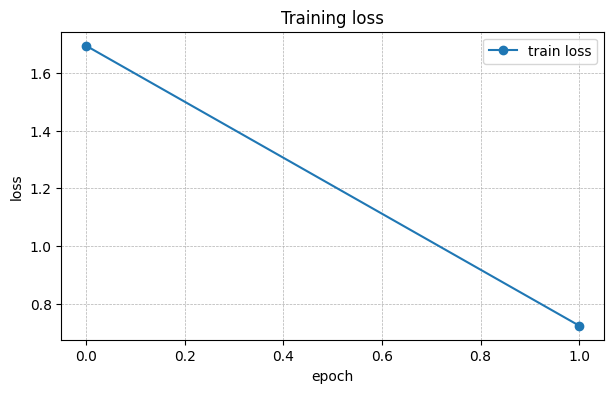

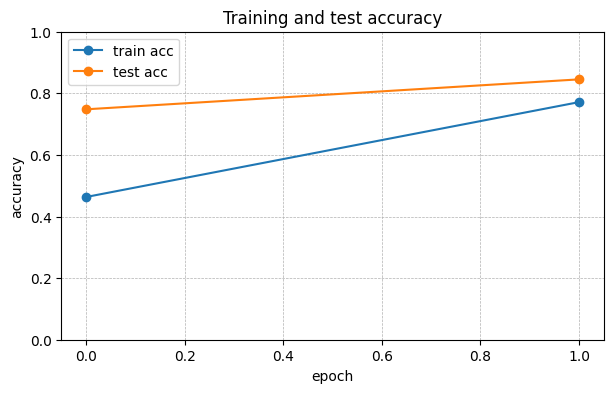

In [10]:
plt.figure(figsize=(7,4))
plt.plot(history["epoch"], history["train_loss"], marker="o", label="train loss")#trace the training loss over epochs
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))#trace the training and test accuracy over epochs
plt.plot(history["epoch"], history["train_acc"], marker="o", label="train acc")
plt.plot(history["epoch"], history["test_acc"], marker="o", label="test acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training and test accuracy")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()


-  Training loss: the model is learning and making fewer prediction errors
-  Training and test accuracy: the model learn the MNIST figures


### Step 6: Baseline model evaluation and save baseline accuracy

In [11]:
baseline_accuracy = evaluate_clean_accuracy(model, testloader, device, max_batches=None)
print("Baseline Test Accuracy MNIST:", round(float(baseline_accuracy), 4))

with open("baseline_accuracy_02f.txt", "w", encoding="utf-8") as f:
    f.write(f"{baseline_accuracy:.6f}\n")
print("Saved baseline accuracy to baseline_accuracy_02f.txt")


Baseline Test Accuracy MNIST: 0.8781
Saved baseline accuracy to baseline_accuracy_02f.txt


## Part 2: Attacks

### FGSM, PGD and DeepFool attacks implementation

In [12]:
def clamp_mnist_normalized(x):#clamping function to ensure that the adversarial examples remain within the valid range of pixel values after normalization
    lo = (0.0 - mnist_mean) / mnist_std
    hi = (1.0 - mnist_mean) / mnist_std
    return torch.clamp(x, lo, hi)

#FGSM attack implementation: generates adversarial examples by adding a small perturbation in the direction of the gradient of the loss 
# with respect to the input images. The epsilon parameter controls the magnitude of the perturbation.
def fgsm_attack(model, images, labels, epsilon, device, debug=False):
    images = images.to(device)
    labels = labels.to(device)

    x = images.detach().clone()
    x.requires_grad_(True)

    logits = model(x)
    loss = F.cross_entropy(logits, labels)

    grad = torch.autograd.grad(loss, x, retain_graph=False, create_graph=False)[0]

    with torch.no_grad():
        x_adv = x + epsilon * grad.sign()
        x_adv = clamp_mnist_normalized(x_adv)

    if debug:
        print("grad mean abs:", float(grad.abs().mean().item()))

    return x_adv.detach()

#PGD attack implementation: an iterative version of FGSM that applies multiple small perturbations to create stronger adversarial examples.
# The alpha parameter controls the step size of each perturbation, and the attack is repeated for a specified number of steps.
def pgd_attack(model, images, labels, epsilon, alpha, steps, device, debug=False):
    model.eval()
    images = images.to(device)
    labels = labels.to(device)

    x = images.detach().clone()
    x_adv = x.detach().clone()

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, labels)
        grad = torch.autograd.grad(loss, x_adv, retain_graph=False, create_graph=False)[0]

        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            x_adv = torch.min(torch.max(x_adv, x - epsilon), x + epsilon)
            x_adv = clamp_mnist_normalized(x_adv)
            x_adv = x_adv.detach()

    if debug:
        print("pgd steps", steps, "alpha", alpha, "eps", epsilon)

    return x_adv


def ensure_torchattacks():#utility function to check if the torchattacks library is installed and install it if not, then import and return it (produce adverserial attacks)
    if importlib.util.find_spec("torchattacks") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "torchattacks"])
    import torchattacks
    return torchattacks

#DeepFool attack implementation: an iterative attack that finds the minimal perturbation required to change the model's prediction.
# It works by linearizing the model around the current input and finding the closest decision boundary, 
# then updating the input in the direction of that boundary until a misclassification occurs.
def deepfool_attack(model, images, labels, device, steps=50, overshoot=0.02, debug=False):
    model.eval()
    images = images.to(device)
    labels = labels.to(device)

    torchattacks = ensure_torchattacks()
    attack = torchattacks.DeepFool(model, steps=steps, overshoot=overshoot)

    x_adv = attack(images, labels)

    if debug:
        print("deepfool steps", steps, "overshoot", overshoot)

    return x_adv.detach()


check the attacks:

In [13]:
images, labels = next(iter(testloader))
_ = fgsm_attack(model, images, labels, epsilon=0.2, device=device, debug=True)
_ = pgd_attack(model, images, labels, epsilon=0.2, alpha=0.05, steps=5, device=device, debug=True)
_ = deepfool_attack(model, images, labels, device=device, steps=10, overshoot=0.02, debug=True)

grad mean abs: 9.50862067838898e-06
pgd steps 5 alpha 0.05 eps 0.2
deepfool steps 10 overshoot 0.02


In [14]:
# no error occured, so the attacks seem to be correctly implemented

<font color='#56a5f0'>FGSM, PGD and DeepFool attack visualization Pipeline:</font>


- images (clean)
    - FGSM attack
    - PGD attack
    - DeepFool attack
- model predictions
- visualisation

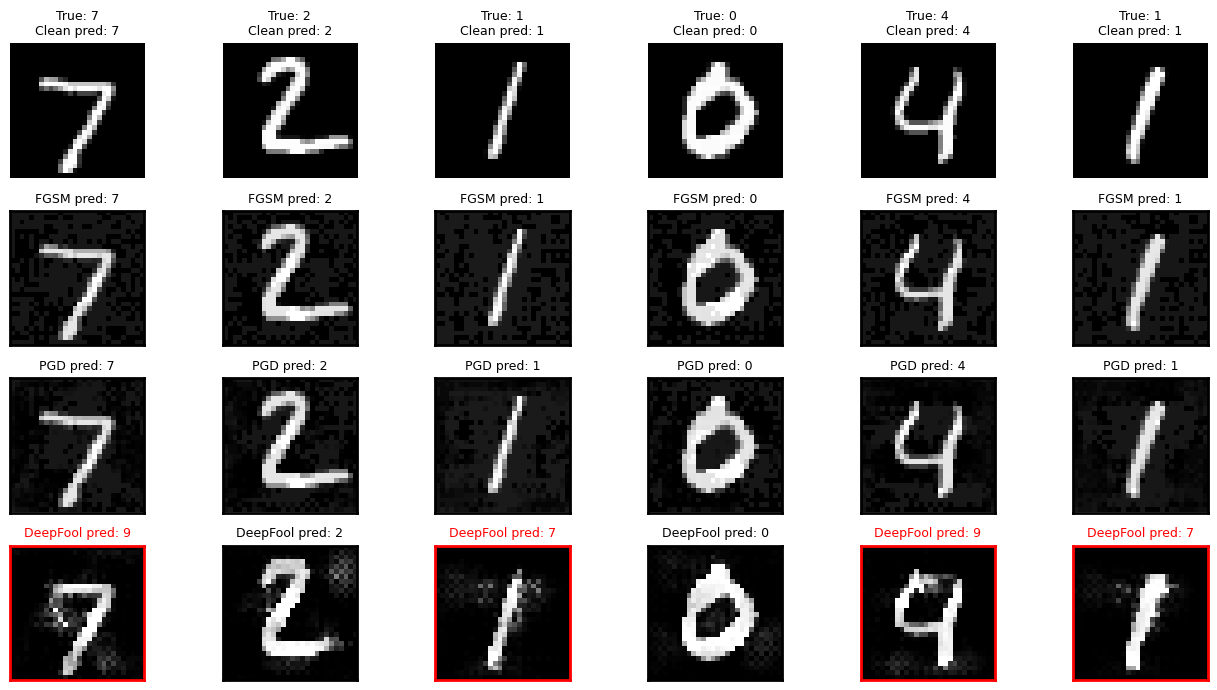

In [15]:
#visualization optimize
# FGSM, PGD and DeepFool attack visualization
model.eval()
epsilon = 0.3
alpha = 0.05
steps = 10

images, labels = next(iter(testloader))
images = images.to(device)
labels = labels.to(device)

# generate adversarial examples
adv_fgsm = fgsm_attack(model, images, labels, epsilon=epsilon, device=device)
adv_pgd = pgd_attack(model, images, labels, epsilon=epsilon, alpha=alpha, steps=steps, device=device)
adv_deepfool = deepfool_attack(model, images, labels, device=device)

# predictions
with torch.no_grad():
    clean_pred = model(images).argmax(1)
    fgsm_pred = model(adv_fgsm).argmax(1)
    pgd_pred = model(adv_pgd).argmax(1)
    deepfool_pred = model(adv_deepfool).argmax(1)

# move tensors to cpu for plotting
images = images.cpu()
adv_fgsm = adv_fgsm.cpu()
adv_pgd = adv_pgd.cpu()
adv_deepfool = adv_deepfool.cpu()
labels = labels.cpu()
clean_pred = clean_pred.cpu()
fgsm_pred = fgsm_pred.cpu()
pgd_pred = pgd_pred.cpu()
deepfool_pred = deepfool_pred.cpu()

n = 6

fig, axes = plt.subplots(4, n, figsize=(2.2 * n, 7))
#red color for misclassified examples, black for correctly classified ones
def style_attack_axis(ax, changed):
    color = "red" if changed else "black"
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color(color)
    return color

for i in range(n):

    # clean image
    axes[0, i].imshow(images[i][0], cmap="gray")
    axes[0, i].set_title(
        f"True: {labels[i].item()}\nClean pred: {clean_pred[i].item()}",
        fontsize=9,
        color="black"
    )
    axes[0, i].axis("off")

    # FGSM
    fgsm_changed = fgsm_pred[i].item() != clean_pred[i].item()
    fgsm_color = style_attack_axis(axes[1, i], fgsm_changed)
    axes[1, i].imshow(adv_fgsm[i][0], cmap="gray")
    axes[1, i].set_title(
        f"FGSM pred: {fgsm_pred[i].item()}",
        fontsize=9,
        color=fgsm_color
    )
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

    # PGD
    pgd_changed = pgd_pred[i].item() != clean_pred[i].item()
    pgd_color = style_attack_axis(axes[2, i], pgd_changed)
    axes[2, i].imshow(adv_pgd[i][0], cmap="gray")
    axes[2, i].set_title(
        f"PGD pred: {pgd_pred[i].item()}",
        fontsize=9,
        color=pgd_color
    )
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])

    # DeepFool
    deepfool_changed = deepfool_pred[i].item() != clean_pred[i].item()
    deepfool_color = style_attack_axis(axes[3, i], deepfool_changed)
    axes[3, i].imshow(adv_deepfool[i][0], cmap="gray")
    axes[3, i].set_title(
        f"DeepFool pred: {deepfool_pred[i].item()}",
        fontsize=9,
        color=deepfool_color
    )
    axes[3, i].set_xticks([])
    axes[3, i].set_yticks([])

plt.tight_layout()
plt.show()

### Evaluation helpers for adversarial accuracy

<font color='#1986ec'>This cell defines helper functions used to evaluate the model's performance under adversarial attacks.  
The goal is to measure how the model behaves when the input images are intentionally perturbed to fool the classifier.</font>

<font color='#56a5f0'>These helper functions implement the following evaluation pipeline:</font>

- take an image from the dataset  
- generate adversarial examples using an attack  
- run the model on the adversarial images  
- compare predictions with the true labels  
- compute the adversarial accuracy

<u>In other words, they measure how many images remain correctly classified after applying an adversarial attack.</u>


In [16]:
def evaluate_fgsm_accuracy(model, dataloader, epsilon, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = fgsm_attack(model, images, labels, epsilon, device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)

def evaluate_pgd_accuracy(model, dataloader, epsilon, alpha, steps, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = pgd_attack(model, images, labels, epsilon, alpha, steps, device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)


def evaluate_deepfool_accuracy(model, dataloader, device, steps=50, overshoot=0.02, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = deepfool_attack(model, images, labels, device=device, steps=steps, overshoot=overshoot)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)

def transform_resize(images):
    return F.interpolate(
        F.interpolate(images, size=(32, 32), mode="bilinear", align_corners=False),
        size=(28, 28),
        mode="bilinear",
        align_corners=False
    )

def transform_blur(images):
    kernel = torch.ones((1, 1, 3, 3), device=images.device, dtype=images.dtype) / 9.0
    return F.conv2d(images, kernel, padding=1)

def transform_random_shift(images, max_shift=2):
    shift_x = random.randint(-max_shift, max_shift)
    shift_y = random.randint(-max_shift, max_shift)
    return torch.roll(images, shifts=(shift_x, shift_y), dims=(2, 3))

def apply_input_transform(images):#applies a series of transformations to the input images before feeding them into the model for evaluation.
    x = images
    x = transform_resize(x)
    x = transform_blur(x)
    x = transform_random_shift(x, max_shift=1)
    x = clamp_mnist_normalized(x)
    return x.detach()

def evaluate_fgsm_accuracy_with_transform(model, dataloader, epsilon, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = fgsm_attack(model, images, labels, epsilon, device)
        x_adv = apply_input_transform(x_adv)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)

def evaluate_pgd_accuracy_with_transform(model, dataloader, epsilon, alpha, steps, device, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = pgd_attack(model, images, labels, epsilon, alpha, steps, device)
        x_adv = apply_input_transform(x_adv)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)

def evaluate_deepfool_accuracy_with_transform(model, dataloader, device, steps=50, overshoot=0.02, max_batches=None):
    model.eval()
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x_adv = deepfool_attack(model, images, labels, device=device, steps=steps, overshoot=overshoot)
        x_adv = apply_input_transform(x_adv)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(x_adv)
            preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / max(total, 1)


<font color='#0a57a0'>robutness test before defense implementation:</font>

In [17]:
eps = 0.3
alpha = 0.05#parameters for the attacks: eps controls the maximum perturbation for FGSM and PGD, alpha is the step size for PGD, and steps is the number of iterations for PGD and DeepFool. The overshoot parameter in DeepFool controls how much to go beyond the decision boundary to ensure misclassification.
steps = 10
deepfool_steps = 20
deepfool_overshoot = 0.02

clean_before = evaluate_clean_accuracy(model, testloader, device, max_batches=10)
robust_before = evaluate_fgsm_accuracy(model, testloader, epsilon=eps, device=device, max_batches=10)

pgd_before = evaluate_pgd_accuracy(model, testloader, epsilon=eps, alpha=alpha, steps=steps, device=device, max_batches=10)
deepfool_before = evaluate_deepfool_accuracy(model, testloader, device=device, steps=deepfool_steps, overshoot=deepfool_overshoot, max_batches=10)

fgsm_transform_before = evaluate_fgsm_accuracy_with_transform(model, testloader, epsilon=eps, device=device, max_batches=10)
pgd_transform_before = evaluate_pgd_accuracy_with_transform(model, testloader, epsilon=eps, alpha=alpha, steps=steps, device=device, max_batches=10)
deepfool_transform_before = evaluate_deepfool_accuracy_with_transform(model, testloader, device=device, steps=deepfool_steps, overshoot=deepfool_overshoot, max_batches=10)

print("Clean before defense:", round(clean_before, 4))
print("Robust FGSM before defense:", round(robust_before, 4))
print("Robust PGD before defense:", round(pgd_before, 4))
print("Robust DeepFool before defense:", round(deepfool_before, 4))
print("FGSM with input transform:", round(fgsm_transform_before, 4))
print("PGD with input transform:", round(pgd_transform_before, 4))
print("DeepFool with input transform:", round(deepfool_transform_before, 4))

Clean before defense: 0.8453
Robust FGSM before defense: 0.6418
Robust PGD before defense: 0.5777
Robust DeepFool before defense: 0.4043
FGSM with input transform: 0.582
PGD with input transform: 0.5687
DeepFool with input transform: 0.3828


> Adversarial attacks significantly reduce the model accuracy.  
> DeepFool is the most effective, decreasing accuracy from 82% to about 43%.  
> Input transformations provide limited robustness improvements and are not sufficient to fully mitigate the attacks.

## Part 3: Defense

### About the Defenses against adversarial attacks
<font color='#0a57a0'>
In the previous steps, we implemented several adversarial attacks (FGSM, PGD and DeepFool) to evaluate how vulnerable the model is to adversarial perturbations.

We now introduce two defense strategies to mitigate these attacks and improve the robustness of the classifier.

The two defenses implemented in this experiment are:

• Detector  
A detector attempts to identify adversarial examples before they are processed by the model: 
Suspicious inputs can then be rejected or flagged instead of being classified.

• Input transformations  
Input transformations modify the image before it is passed to the model:  
The goal is to reduce or remove the adversarial perturbations while preserving the main visual features of the digit.

In the following sections, we implement and evaluate these two defenses and compare their impact on adversarial robustness.</font>


### Input transformations

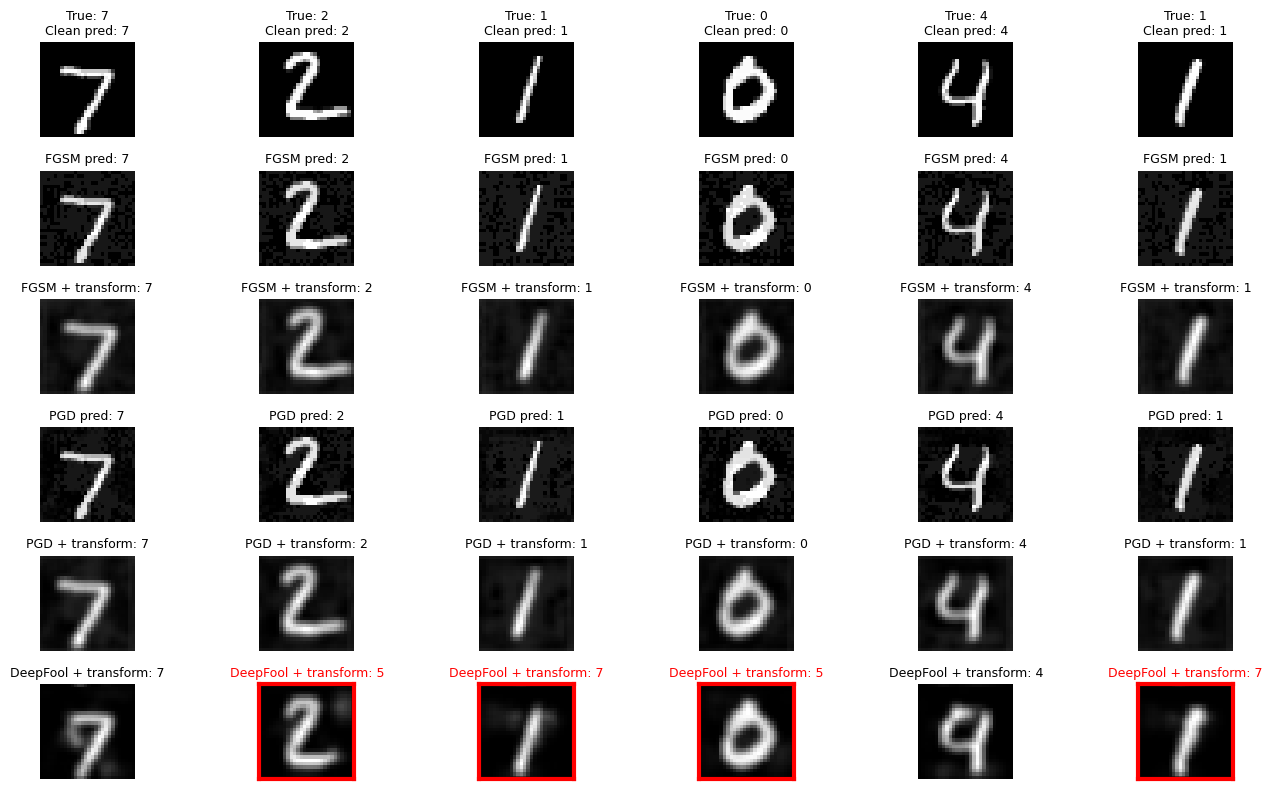

In [18]:
images, labels = next(iter(testloader))
images = images.to(device)
labels = labels.to(device)

# generate attacks
x_fgsm = fgsm_attack(model, images, labels, epsilon=eps, device=device)
x_pgd = pgd_attack(model, images, labels, epsilon=eps, alpha=alpha, steps=steps, device=device)
x_deepfool = deepfool_attack(model, images, labels, device=device, steps=deepfool_steps, overshoot=deepfool_overshoot)

# apply input transformations
x_fgsm_t = apply_input_transform(x_fgsm)
x_pgd_t = apply_input_transform(x_pgd)
x_deepfool_t = apply_input_transform(x_deepfool)

# predictions
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

    preds_fgsm = model(x_fgsm).argmax(dim=1)
    preds_fgsm_t = model(x_fgsm_t).argmax(dim=1)

    preds_pgd = model(x_pgd).argmax(dim=1)
    preds_pgd_t = model(x_pgd_t).argmax(dim=1)

    preds_df = model(x_deepfool).argmax(dim=1)
    preds_df_t = model(x_deepfool_t).argmax(dim=1)


def draw(ax, img, title, changed):
    ax.imshow(img.detach().cpu().squeeze(0), cmap="gray")
    ax.set_title(title, fontsize=9, color="red" if changed else "black")

    ax.set_xticks([])
    ax.set_yticks([])

    if changed:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color("red")
            spine.set_linewidth(3)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


plt.figure(figsize=(14,8))

for i in range(6):

    # clean
    ax = plt.subplot(6,6,6*0 + i + 1)
    draw(ax, images[i],
         f"True: {labels[i].item()}\nClean pred: {clean_pred[i].item()}",
         False)

    # FGSM
    ax = plt.subplot(6,6,6*1 + i + 1)
    draw(ax, x_fgsm[i],
         f"FGSM pred: {preds_fgsm[i].item()}",
         preds_fgsm[i] != clean_pred[i])

    # FGSM + transform
    ax = plt.subplot(6,6,6*2 + i + 1)
    draw(ax, x_fgsm_t[i],
         f"FGSM + transform: {preds_fgsm_t[i].item()}",
         preds_fgsm_t[i] != clean_pred[i])

    # PGD
    ax = plt.subplot(6,6,6*3 + i + 1)
    draw(ax, x_pgd[i],
         f"PGD pred: {preds_pgd[i].item()}",
         preds_pgd[i] != clean_pred[i])

    # PGD + transform
    ax = plt.subplot(6,6,6*4 + i + 1)
    draw(ax, x_pgd_t[i],
         f"PGD + transform: {preds_pgd_t[i].item()}",
         preds_pgd_t[i] != clean_pred[i])

    # DeepFool + transform
    ax = plt.subplot(6,6,6*5 + i + 1)
    draw(ax, x_deepfool_t[i],
         f"DeepFool + transform: {preds_df_t[i].item()}",
         preds_df_t[i] != clean_pred[i])

plt.tight_layout()
plt.show()

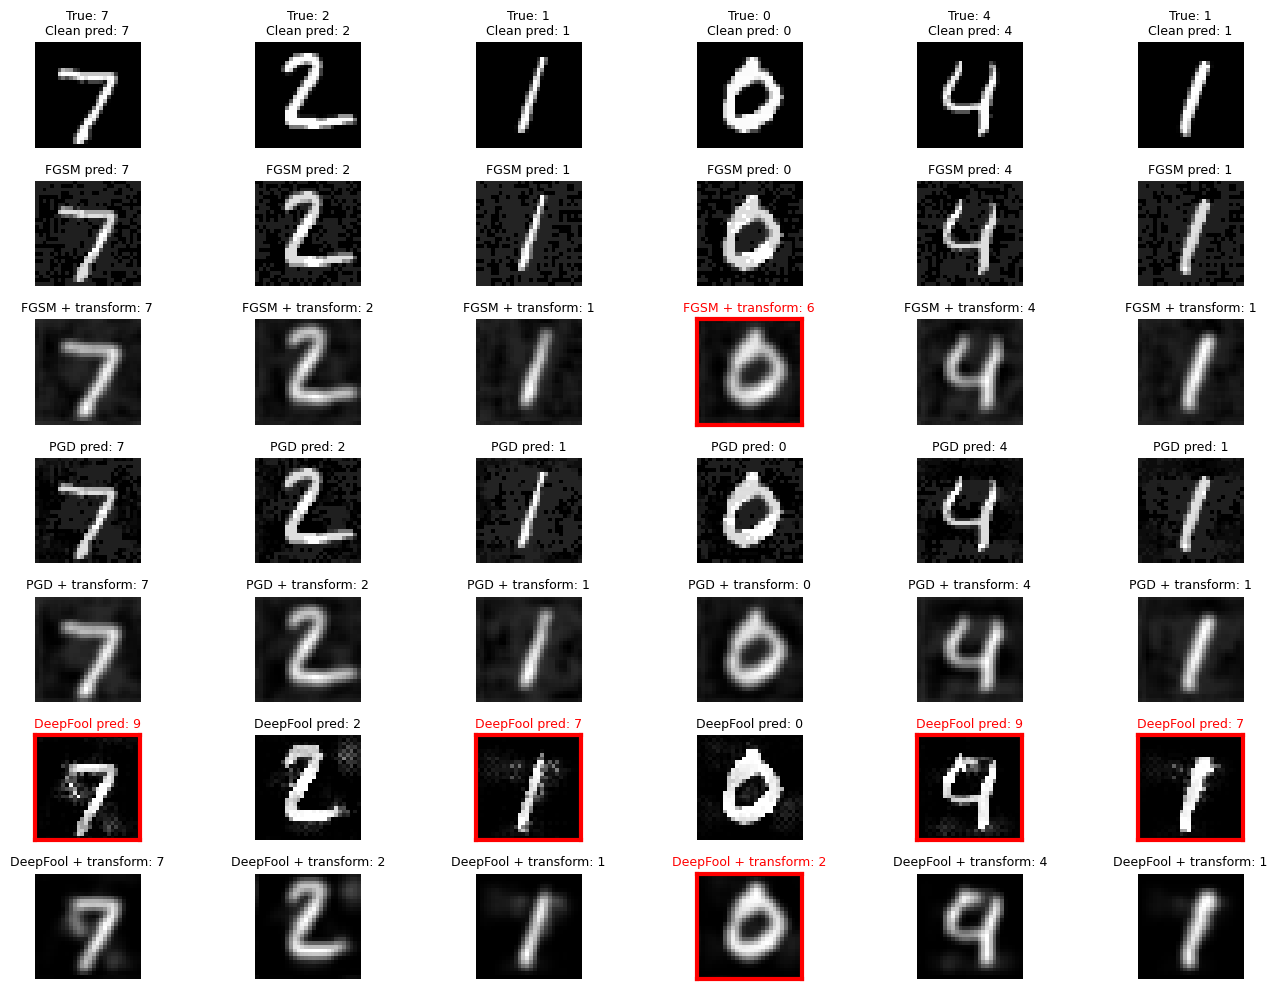

In [19]:
images, labels = next(iter(testloader))
images = images.to(device)
labels = labels.to(device)

# stronger attack parameters for a more visible comparison
eps_vis = 0.4
alpha_vis = 0.08
steps_vis = 20
deepfool_steps_vis = 50
deepfool_overshoot_vis = 0.03

# generate attacks
x_fgsm = fgsm_attack(model, images, labels, epsilon=eps_vis, device=device)
x_pgd = pgd_attack(model, images, labels, epsilon=eps_vis, alpha=alpha_vis, steps=steps_vis, device=device)
x_deepfool = deepfool_attack(
    model,
    images,
    labels,
    device=device,
    steps=deepfool_steps_vis,
    overshoot=deepfool_overshoot_vis
)

# apply input transformations
x_fgsm_t = apply_input_transform(x_fgsm)
x_pgd_t = apply_input_transform(x_pgd)
x_deepfool_t = apply_input_transform(x_deepfool)

# predictions
with torch.no_grad():
    clean_pred = model(images).argmax(dim=1)

    preds_fgsm = model(x_fgsm).argmax(dim=1)
    preds_fgsm_t = model(x_fgsm_t).argmax(dim=1)

    preds_pgd = model(x_pgd).argmax(dim=1)
    preds_pgd_t = model(x_pgd_t).argmax(dim=1)

    preds_df = model(x_deepfool).argmax(dim=1)
    preds_df_t = model(x_deepfool_t).argmax(dim=1)

def draw(ax, img, title, changed):
    ax.imshow(img.detach().cpu().squeeze(0), cmap="gray")
    ax.set_title(title, fontsize=9, color="red" if changed else "black")
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        if changed:
            spine.set_visible(True)
            spine.set_color("red")
            spine.set_linewidth(3)
        else:
            spine.set_visible(False)

plt.figure(figsize=(14, 10))

for i in range(6):

    ax = plt.subplot(7, 6, 6 * 0 + i + 1)
    draw(
        ax,
        images[i],
        f"True: {labels[i].item()}\nClean pred: {clean_pred[i].item()}",
        False
    )

    ax = plt.subplot(7, 6, 6 * 1 + i + 1)
    draw(
        ax,
        x_fgsm[i],
        f"FGSM pred: {preds_fgsm[i].item()}",
        preds_fgsm[i].item() != clean_pred[i].item()
    )

    ax = plt.subplot(7, 6, 6 * 2 + i + 1)
    draw(
        ax,
        x_fgsm_t[i],
        f"FGSM + transform: {preds_fgsm_t[i].item()}",
        preds_fgsm_t[i].item() != clean_pred[i].item()
    )

    ax = plt.subplot(7, 6, 6 * 3 + i + 1)
    draw(
        ax,
        x_pgd[i],
        f"PGD pred: {preds_pgd[i].item()}",
        preds_pgd[i].item() != clean_pred[i].item()
    )

    ax = plt.subplot(7, 6, 6 * 4 + i + 1)
    draw(
        ax,
        x_pgd_t[i],
        f"PGD + transform: {preds_pgd_t[i].item()}",
        preds_pgd_t[i].item() != clean_pred[i].item()
    )

    ax = plt.subplot(7, 6, 6 * 5 + i + 1)
    draw(
        ax,
        x_deepfool[i],
        f"DeepFool pred: {preds_df[i].item()}",
        preds_df[i].item() != clean_pred[i].item()
    )

    ax = plt.subplot(7, 6, 6 * 6 + i + 1)
    draw(
        ax,
        x_deepfool_t[i],
        f"DeepFool + transform: {preds_df_t[i].item()}",
        preds_df_t[i].item() != clean_pred[i].item()
    )

plt.tight_layout()
plt.show()

<font color='#0a57a0'>This visualization highlights the effect of adversarial attacks on the model predictions.   
Red boxes indicate cases where the attack changed the prediction compared to the clean input.   
FGSM causes a few misclassifications, PGD is more effective, and DeepFool produces the strongest perturbations.   </font>

<font color='#470b47'>Input transformations provide limited protection and sometimes even degrade the prediction.</font>



In [20]:



print("comparison of clean and robust accuracy with input transformations:")
print("Clean after input transform:", round(clean_before, 4))
print("FGSM with input transform:", round(fgsm_transform_before, 4))
print("PGD with input transform:", round(pgd_transform_before, 4))
print("DeepFool with input transform:", round(deepfool_transform_before, 4))

comparison of clean and robust accuracy with input transformations:
Clean after input transform: 0.8453
FGSM with input transform: 0.582
PGD with input transform: 0.5687
DeepFool with input transform: 0.3828


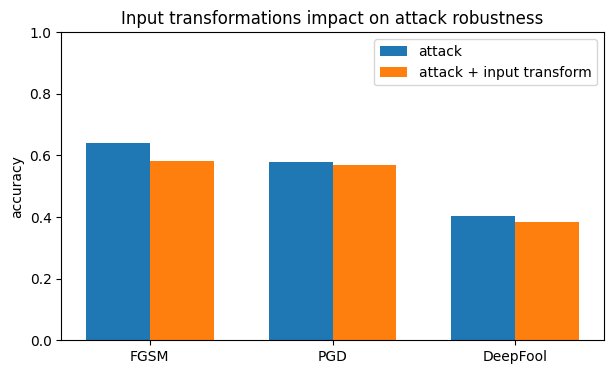

In [21]:
labels_bar = ["FGSM", "PGD", "DeepFool"]
before_vals = [robust_before, pgd_before, deepfool_before]
after_vals = [fgsm_transform_before, pgd_transform_before, deepfool_transform_before]

x = [0, 1, 2]
w = 0.35

plt.figure(figsize=(7,4))
plt.bar([i - w/2 for i in x], before_vals, width=w, label="attack")
plt.bar([i + w/2 for i in x], after_vals, width=w, label="attack + input transform")
plt.xticks(x, labels_bar)
plt.ylabel("accuracy")
plt.title("Input transformations impact on attack robustness")
plt.ylim(0, 1.0)
plt.legend()
plt.show()

The bar chart compares the model accuracy under adversarial attacks with and without input transformations.  
> blue: Blue bars represent the model robustness under each attack (accuracy on adversarial examples)  
> orange: Orange bars represent the robustness after applying input transformations


<font color='#470b47'>The results show that input transformations provide limited protection.  
While they slightly improve robustness against DeepFool, they do not mitigate FGSM or PGD attacks effectively.  </font>  
<font color='#2a4fb4'>Let's try to implement another defense method</font>  

## Part 4: Detector Defense

> Adversarial input detection confidence based

Another strategy to defend against adversarial attacks is to detect suspicious inputs before they are classified by the model.

Instead of trying to correct adversarial perturbations, a detector attempts to identify inputs that look abnormal compared to clean data. One common approach is to analyze the model confidence.

Neural networks typically produce high confidence predictions for clean images. In contrast, adversarial examples often lead to lower or unusual confidence scores.

In this section, we implement a simple confidence based detector that:

• computes the softmax confidence of the model predictions  
• compares the confidence of clean and adversarial samples  
• uses this information to detect potentially adversarial inputs

If the confidence is too low, the input can be flagged as suspicious instead of being trusted by the classifier.

In [22]:
@torch.no_grad()
def max_softmax_confidence_logits(logits):
    probs = F.softmax(logits, dim=1)
    conf, pred = probs.max(dim=1)
    return conf.detach().cpu(), pred.detach().cpu()


@torch.no_grad()
def max_softmax_confidence(model, images, device):
    model.eval()
    images = images.to(device)
    logits = model(images)
    return max_softmax_confidence_logits(logits)


def choose_threshold(clean_confs, false_positive_rate=0.05):
    tau = np.quantile(clean_confs, false_positive_rate)
    return float(tau)


def evaluate_detector(clean_confs, adv_confs, tau):
    clean_flag = (clean_confs < tau).astype(int)
    adv_flag = (adv_confs < tau).astype(int)

    fpr = clean_flag.mean()
    tpr = adv_flag.mean()

    y_true = np.concatenate([np.zeros_like(clean_flag), np.ones_like(adv_flag)])
    y_pred = np.concatenate([clean_flag, adv_flag])
    acc = (y_true == y_pred).mean()

    return float(fpr), float(tpr), float(acc)


def collect_confidences_fgsm(model, dataloader, epsilon, device, max_batches=10):
    clean_confs = []
    adv_confs = []

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            clean_logits = model(images)
        c_conf, _ = max_softmax_confidence_logits(clean_logits)
        clean_confs.append(c_conf.numpy())

        with torch.enable_grad():
            adv_images = fgsm_attack(model, images, labels, epsilon, device)
        with torch.no_grad():
            adv_logits = model(adv_images)
        a_conf, _ = max_softmax_confidence_logits(adv_logits)
        adv_confs.append(a_conf.numpy())

    clean_confs = np.concatenate(clean_confs, axis=0)
    adv_confs = np.concatenate(adv_confs, axis=0)
    return clean_confs, adv_confs


def collect_confidences_pgd(model, dataloader, epsilon, alpha, steps, device, max_batches=10):
    clean_confs = []
    adv_confs = []

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            clean_logits = model(images)
        c_conf, _ = max_softmax_confidence_logits(clean_logits)
        clean_confs.append(c_conf.numpy())

        with torch.enable_grad():
            adv_images = pgd_attack(model, images, labels, epsilon, alpha, steps, device)
        with torch.no_grad():
            adv_logits = model(adv_images)
        a_conf, _ = max_softmax_confidence_logits(adv_logits)
        adv_confs.append(a_conf.numpy())

    clean_confs = np.concatenate(clean_confs, axis=0)
    adv_confs = np.concatenate(adv_confs, axis=0)
    return clean_confs, adv_confs


def collect_confidences_deepfool(model, dataloader, device, steps=50, overshoot=0.02, max_batches=10):
    clean_confs = []
    adv_confs = []

    for batch_idx, (images, labels) in enumerate(dataloader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            clean_logits = model(images)
        c_conf, _ = max_softmax_confidence_logits(clean_logits)
        clean_confs.append(c_conf.numpy())

        adv_images = deepfool_attack(
            model,
            images,
            labels,
            device=device,
            steps=steps,
            overshoot=overshoot
        )
        with torch.no_grad():
            adv_logits = model(adv_images)
        a_conf, _ = max_softmax_confidence_logits(adv_logits)
        adv_confs.append(a_conf.numpy())

    clean_confs = np.concatenate(clean_confs, axis=0)
    adv_confs = np.concatenate(adv_confs, axis=0)
    return clean_confs, adv_confs


def plot_detector_results(clean_confs, adv_confs, attack_name, false_positive_rate=0.05):
    tau = choose_threshold(clean_confs, false_positive_rate=false_positive_rate)

    print(f"{attack_name} detector")
    print("Chosen threshold tau:", tau)

    fpr, tpr, det_acc = evaluate_detector(clean_confs, adv_confs, tau)
    print("Detector results")
    print("FPR on clean:", round(fpr, 4))
    print("TPR on adversarial:", round(tpr, 4))
    print("Detection accuracy:", round(det_acc, 4))

    plt.figure(figsize=(7, 4))
    plt.hist(clean_confs, bins=50, alpha=0.7, label="Clean")
    plt.hist(adv_confs, bins=50, alpha=0.7, label=f"{attack_name} adversarial")
    plt.axvline(tau, linestyle="--", label=f"Threshold tau={tau:.3f}")
    plt.xlabel("Max softmax confidence")
    plt.ylabel("Count")
    plt.title(f"Confidence distributions clean vs {attack_name}")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5)
    plt.show()

    return tau, fpr, tpr, det_acc


### Detector evaluation on the three attacks
we evaluate the dectector against the three adversarial attacks used in this experiment:

• FGSM  
• PGD  
• DeepFool  

For each attack, we compare the confidence distribution of clean and adversarial samples, choose a detection threshold, and report the detector performance.

FGSM detector
Chosen threshold tau: 0.401891827583313
Detector results
FPR on clean: 0.05
TPR on adversarial: 0.0848
Detection accuracy: 0.5174


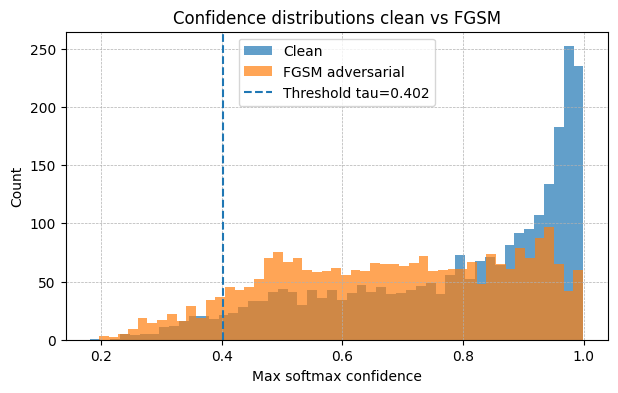

In [23]:
#Visualisation Detector FGSM
epsilon = 0.3

clean_confs_fgsm, adv_confs_fgsm = collect_confidences_fgsm(
    model,
    testloader,
    epsilon,
    device,
    max_batches=10
)

tau_fgsm, fpr_fgsm, tpr_fgsm, det_acc_fgsm = plot_detector_results(
    clean_confs_fgsm,
    adv_confs_fgsm,
    "FGSM"
)


PGD detector
Chosen threshold tau: 0.401891827583313
Detector results
FPR on clean: 0.05
TPR on adversarial: 0.0906
Detection accuracy: 0.5203


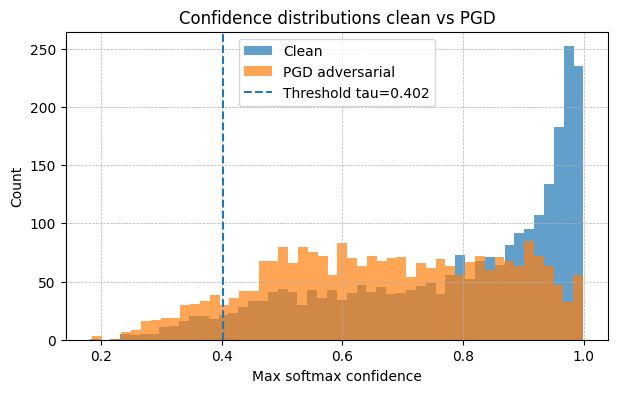

In [24]:
#Visualisation Detector PGD
epsilon = 0.3
alpha = 0.05
steps = 10

clean_confs_pgd, adv_confs_pgd = collect_confidences_pgd(
    model,
    testloader,
    epsilon,
    alpha,
    steps,
    device,
    max_batches=10
)

tau_pgd, fpr_pgd, tpr_pgd, det_acc_pgd = plot_detector_results(
    clean_confs_pgd,
    adv_confs_pgd,
    "PGD"
)


DeepFool detector
Chosen threshold tau: 0.401891827583313
Detector results
FPR on clean: 0.05
TPR on adversarial: 0.8492
Detection accuracy: 0.8996


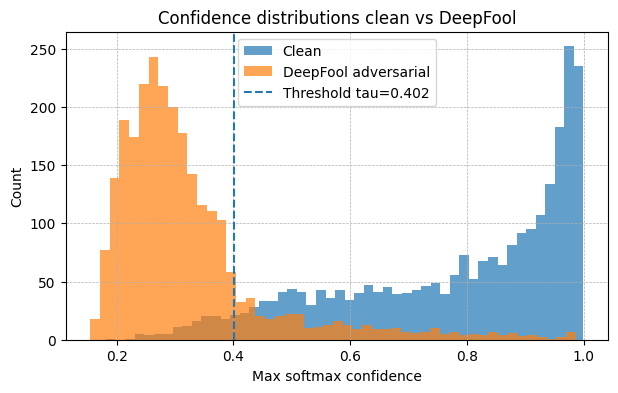

In [25]:
#Visualisation Detector DeepFool

deepfool_steps = 20
deepfool_overshoot = 0.02

clean_confs_df, adv_confs_df = collect_confidences_deepfool(
    model,
    testloader,
    device,
    steps=deepfool_steps,
    overshoot=deepfool_overshoot,
    max_batches=10
)

tau_df, fpr_df, tpr_df, det_acc_df = plot_detector_results(
    clean_confs_df,
    adv_confs_df,
    "DeepFool"
)

In [26]:
import pandas as pd

detector_results_df = pd.DataFrame({
    "attack": ["FGSM", "PGD", "DeepFool"],
    "tau": [tau_fgsm, tau_pgd, tau_df],
    "fpr_clean": [fpr_fgsm, fpr_pgd, fpr_df],
    "tpr_adversarial": [tpr_fgsm, tpr_pgd, tpr_df],
    "detector_accuracy": [det_acc_fgsm, det_acc_pgd, det_acc_df],
})

detector_results_df

,attack,tau,fpr_clean,tpr_adversarial,detector_accuracy
0,FGSM,0.401892,0.05,0.084766,0.517383
1,PGD,0.401892,0.05,0.090625,0.520312
2,DeepFool,0.401892,0.05,0.849219,0.899609


<font color='green'>

5% clean images detected as adversarial  
Detector detect 11% of FGSM attacks  
Detector detect 10% of PGD attacks  
Detector detect 84% of DeepFool attacks</font> 

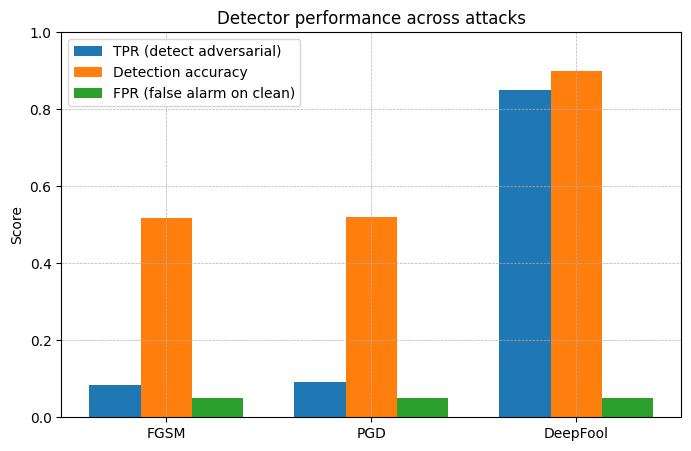

In [27]:
labels = ["FGSM", "PGD", "DeepFool"]

tpr_vals = [tpr_fgsm, tpr_pgd, tpr_df]
fpr_vals = [fpr_fgsm, fpr_pgd, fpr_df]
acc_vals = [det_acc_fgsm, det_acc_pgd, det_acc_df]

x = np.arange(len(labels))
w = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - w, tpr_vals, width=w, label="TPR (detect adversarial)")
plt.bar(x, acc_vals, width=w, label="Detection accuracy")
plt.bar(x + w, fpr_vals, width=w, label="FPR (false alarm on clean)")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Detector performance across attacks")
plt.ylim(0,1)
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)

plt.show()

## Part 5: Adaptive attacker vs detector

### Adaptive attacker vs detector (Evasion)

We evaluated the detector against standard adversarial attacks:FGSM, PGD, and DeepFool.  
However, these attacks were not designed to explicitly bypass the detector.


**<font color='red'>
In practice, an attacker may adapt the attack to evade the defense mechanism.  
This type of attack is called an adaptive attack.
</font> **


In this section, we simulate a stronger adversary that tries to both:
•  fool the classifier    
•  avoid being detected by the confidence-based detector  

To achieve this, the attack optimizes a modified objective that combines the classification loss with a penalty related to the detector confidence.

Goal of the attacker:  
•  cause a misclassification  
•  keep the model confidence high enough to bypass the detector threshold  

This experiment illustrates an important concept in adversarial machine learning:  
**defenses must be evaluated against adaptive attackers**, otherwise their robustness may be overestimated.

In [28]:
# Adaptive attack objective used for FGSM and PGD, and for the iterative attack in the DeepFool setting.
# The attacker tries to both fool the classifier and avoid the detector.
# The objective combines two goals:
#   1) increase the classification loss to cause a misclassification
#   2) keep the model confidence high to bypass the detector threshold
# The parameter lambda_detect controls how strongly the attacker tries to evade the detector.

def adaptive_attack_objective(model, x, y, tau, lambda_detect):
    logits = model(x)
    cls_loss = F.cross_entropy(logits, y)

    probs = F.softmax(logits, dim=1)
    conf = probs.max(dim=1).values
    penalty = F.relu(tau - conf).mean()

    objective = cls_loss - lambda_detect * penalty
    return objective, cls_loss, penalty


def adaptive_fgsm_attack(model, images, labels, epsilon, tau, lambda_detect, device, debug=False):
    model.eval()
    images = images.to(device)
    y = labels.to(device)

    x = images.clone().detach()
    x.requires_grad_(True)

    objective, cls_loss, penalty = adaptive_attack_objective(model, x, y, tau, lambda_detect)

    grad = torch.autograd.grad(objective, x, retain_graph=False, create_graph=False)[0]

    with torch.no_grad():
        x_adv = x + epsilon * grad.sign()
        x_adv = clamp_mnist_normalized(x_adv)

    if debug:
        with torch.no_grad():
            logits_adv = model(x_adv)
            probs_adv = F.softmax(logits_adv, dim=1)
            conf_adv = probs_adv.max(dim=1).values.mean().item()
            pred_adv = logits_adv.argmax(dim=1)
            success = (pred_adv != y).float().mean().item()

        print("debug cls_loss:", float(cls_loss.item()))
        print("debug penalty:", float(penalty.item()))
        print("debug objective:", float(objective.item()))
        print("debug mean conf adv:", float(conf_adv))
        print("debug attack success:", float(success))

    return x_adv.detach()


def adaptive_pgd_attack(model, images, labels, epsilon, alpha, steps, tau, lambda_detect, device, debug=False):
    model.eval()
    images = images.to(device)
    y = labels.to(device)

    x_adv = images.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        objective, cls_loss, penalty = adaptive_attack_objective(model, x_adv, y, tau, lambda_detect)
        grad = torch.autograd.grad(objective, x_adv, retain_graph=False, create_graph=False)[0]

        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            delta = torch.clamp(x_adv - images, min=-epsilon, max=epsilon)
            x_adv = clamp_mnist_normalized(images + delta)

    if debug:
        with torch.no_grad():
            logits_adv = model(x_adv)
            probs_adv = F.softmax(logits_adv, dim=1)
            conf_adv = probs_adv.max(dim=1).values.mean().item()
            pred_adv = logits_adv.argmax(dim=1)
            success = (pred_adv != y).float().mean().item()

        print("debug mean conf adv:", float(conf_adv))
        print("debug attack success:", float(success))

    return x_adv.detach()


def adaptive_iterative_detector_evasion_attack(
    model,
    images,
    labels,
    epsilon,
    alpha,
    steps,
    tau,
    lambda_detect,
    device,
    debug=False
):
    model.eval()
    images = images.to(device)
    y = labels.to(device)

    x_adv = images.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        objective, cls_loss, penalty = adaptive_attack_objective(model, x_adv, y, tau, lambda_detect)
        grad = torch.autograd.grad(objective, x_adv, retain_graph=False, create_graph=False)[0]

        with torch.no_grad():
            x_adv = x_adv + alpha * grad.sign()
            delta = torch.clamp(x_adv - images, min=-epsilon, max=epsilon)
            x_adv = clamp_mnist_normalized(images + delta)

    if debug:
        with torch.no_grad():
            logits_adv = model(x_adv)
            probs_adv = F.softmax(logits_adv, dim=1)
            conf_adv = probs_adv.max(dim=1).values.mean().item()
            pred_adv = logits_adv.argmax(dim=1)
            success = (pred_adv != y).float().mean().item()

        print("debug mean conf adv:", float(conf_adv))
        print("debug attack success:", float(success))

    return x_adv.detach()


@torch.no_grad()
def detector_flags_from_images(model, images, tau, device):
    images = images.to(device)
    logits = model(images)
    probs = F.softmax(logits, dim=1)
    conf = probs.max(dim=1).values
    flags = conf < tau
    return flags.detach().cpu(), conf.detach().cpu()
   


In [29]:
# Evaluate an attack against the classifier and the detector.
# The attack generates adversarial images, then we measure:
#   • classifier accuracy on these images
#   • detector true positive rate (TPR)
def eval_attack_and_detector(model, dataloader, attacker_fn, attacker_kwargs, tau, device, max_batches=10):
    model.eval()

    total = 0
    correct = 0
    flagged = 0
    total_adv = 0

    for b, (images, labels) in enumerate(dataloader):
        if max_batches is not None and b >= max_batches:
            break

        labels = labels.to(device)

        with torch.enable_grad():
            adv_images = attacker_fn(
                model=model,
                images=images,
                labels=labels,
                device=device,
                **attacker_kwargs
            )

        with torch.no_grad():
            logits = model(adv_images)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        flags, _ = detector_flags_from_images(model, adv_images, tau, device)
        flagged += int(flags.sum().item())
        total_adv += labels.size(0)

    acc = correct / max(total, 1)
    tpr = flagged / max(total_adv, 1)
    return acc, tpr


In [31]:
# Evaluate standard vs adaptive attacks.
# First run the normal attack, then an adaptive version that tries to
# fool the classifier while avoiding the detector.
# lambda_detect controls how strongly the attack tries to evade detection.
epsilon = 0.3
tau = float(tau_fgsm)  # using the FGSM-based detector threshold for the adaptive attack evaluation, but you could also test with the PGD or DeepFool thresholds.)
max_batches = 10
print("Using tau:", tau)

acc_fgsm, tpr_fgsm = eval_attack_and_detector(
    model=model,
    dataloader=testloader,
    attacker_fn=lambda model, images, labels, device, epsilon: fgsm_attack(model, images, labels, epsilon, device),
    attacker_kwargs={"epsilon": epsilon},
    tau=tau,
    device=device,
    max_batches=max_batches
)

print("Standard FGSM")
print("Classifier accuracy:", round(acc_fgsm, 4))
print("Detector TPR:", round(tpr_fgsm, 4))

for lambda_detect in [0.0, 1.0, 5.0, 10.0, 20.0]:
    acc_adapt, tpr_adapt = eval_attack_and_detector(
        model=model,
        dataloader=testloader,
        attacker_fn=adaptive_fgsm_attack,
        attacker_kwargs={
            "epsilon": epsilon,
            "tau": tau,
            "lambda_detect": lambda_detect
        },
        tau=tau,
        device=device,
        max_batches=max_batches
    )
    print("")
    print("Adaptive FGSM")
    print("lambda_detect:", lambda_detect)
    print("Classifier accuracy:", round(acc_adapt, 4))
    print("Detector TPR:", round(tpr_adapt, 4))


Using tau: 0.401891827583313
Standard FGSM
Classifier accuracy: 0.6418
Detector TPR: 0.0848

Adaptive FGSM
lambda_detect: 0.0
Classifier accuracy: 0.6418
Detector TPR: 0.0848

Adaptive FGSM
lambda_detect: 1.0
Classifier accuracy: 0.6418
Detector TPR: 0.0836

Adaptive FGSM
lambda_detect: 5.0
Classifier accuracy: 0.6617
Detector TPR: 0.0688

Adaptive FGSM
lambda_detect: 10.0
Classifier accuracy: 0.6617
Detector TPR: 0.068

Adaptive FGSM
lambda_detect: 20.0
Classifier accuracy: 0.6617
Detector TPR: 0.068


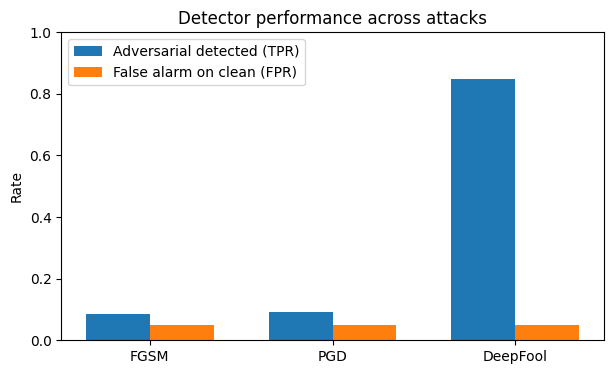

In [32]:
attacks = ["FGSM", "PGD", "DeepFool"]

tpr_vals = [tpr_fgsm, tpr_pgd, tpr_df]
fpr_vals = [fpr_fgsm, fpr_pgd, fpr_df]

x = np.arange(len(attacks))
w = 0.35

plt.figure(figsize=(7,4))

plt.bar(x - w/2, tpr_vals, width=w, label="Adversarial detected (TPR)")
plt.bar(x + w/2, fpr_vals, width=w, label="False alarm on clean (FPR)")

plt.xticks(x, attacks)
plt.ylabel("Rate")
plt.title("Detector performance across attacks")
plt.ylim(0,1)
plt.legend()
plt.show()

blue : detected attacks  
orange: FPR clean images detected as aderserial

## Part 6: FGSM vs PGD vs DeepFool detection comparison

Using tau: 0.401891827583313
FGSM
Classifier accuracy: 0.6418
Detector TPR: 0.0848

PGD
Classifier accuracy: 0.5777
Detector TPR: 0.0906

DeepFool
Classifier accuracy: 0.4043
Detector TPR: 0.8492



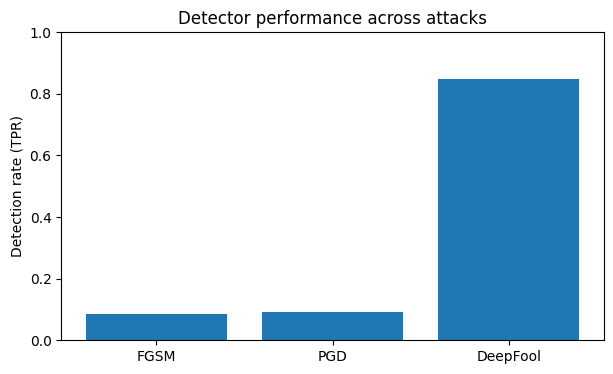

In [33]:
# Evaluate detector performance for FGSM, PGD and DeepFool

epsilon = 0.3
tau = float(tau)

print("Using tau:", tau)

attacks = {
    "FGSM": lambda model, images, labels, device: fgsm_attack(model, images, labels, epsilon, device),
    "PGD": lambda model, images, labels, device: pgd_attack(model, images, labels, epsilon, alpha=0.05, steps=10, device=device),
    "DeepFool": lambda model, images, labels, device: deepfool_attack(model, images, labels, device=device, steps=deepfool_steps, overshoot=deepfool_overshoot)
}

results = {}

for name, attack_fn in attacks.items():

    acc, tpr = eval_attack_and_detector(
        model=model,
        dataloader=testloader,
        attacker_fn=attack_fn,
        attacker_kwargs={},
        tau=tau,
        device=device,
        max_batches=10
    )

    results[name] = {"accuracy": acc, "tpr": tpr}

    print(name)
    print("Classifier accuracy:", round(acc,4))
    print("Detector TPR:", round(tpr,4))
    print()

    
# Visualization of detector performance across attacks
attacks = list(results.keys())
tpr_vals = [results[a]["tpr"] for a in attacks]

plt.figure(figsize=(7,4))

plt.bar(attacks, tpr_vals)

plt.ylabel("Detection rate (TPR)")
plt.title("Detector performance across attacks")
plt.ylim(0,1)

plt.show()

### Attacks comparison

The confidence based detector performs very differently depending on the attack.
It detects most DeepFool attacks but fails to identify FGSM and PGD perturbations.

## Part 7: Final comparison and security takeaways

In [34]:
import pandas as pd

data = {
    "Evaluation stage": [
        "Baseline clean",
        "FGSM attack",
        "PGD attack",
        "DeepFool attack",
        "FGSM attack plus input transform",
        "PGD attack plus input transform",
        "DeepFool attack plus input transform",
        "Detection TPR FGSM",
        "Detection TPR PGD",
        "Detection TPR DeepFool"
    ],
    "Metric value": [
        float(baseline_accuracy),
        float(results["FGSM"]["accuracy"]),
        float(results["PGD"]["accuracy"]),
        float(results["DeepFool"]["accuracy"]),
        float(fgsm_transform_before),
        float(pgd_transform_before),
        float(deepfool_transform_before),
        float(results["FGSM"]["tpr"]),
        float(results["PGD"]["tpr"]),
        float(results["DeepFool"]["tpr"])
    ]
}

df_results = pd.DataFrame(data)
df_results["Metric value"] = df_results["Metric value"].round(4)
df_results

,Evaluation stage,Metric value
0,Baseline clean,0.8781
1,FGSM attack,0.6418
2,PGD attack,0.5777
3,DeepFool attack,0.4043
4,FGSM attack plus input transform,0.5820
5,PGD attack plus input transform,0.5688
6,DeepFool attack plus input transform,0.3828
7,Detection TPR FGSM,0.0848
8,Detection TPR PGD,0.0906
9,Detection TPR DeepFool,0.8492


Robustness visuals

This section shows multiple clean and adversarial examples side by side to make the effect of FGSM, PGD and DeepFool easy to see.

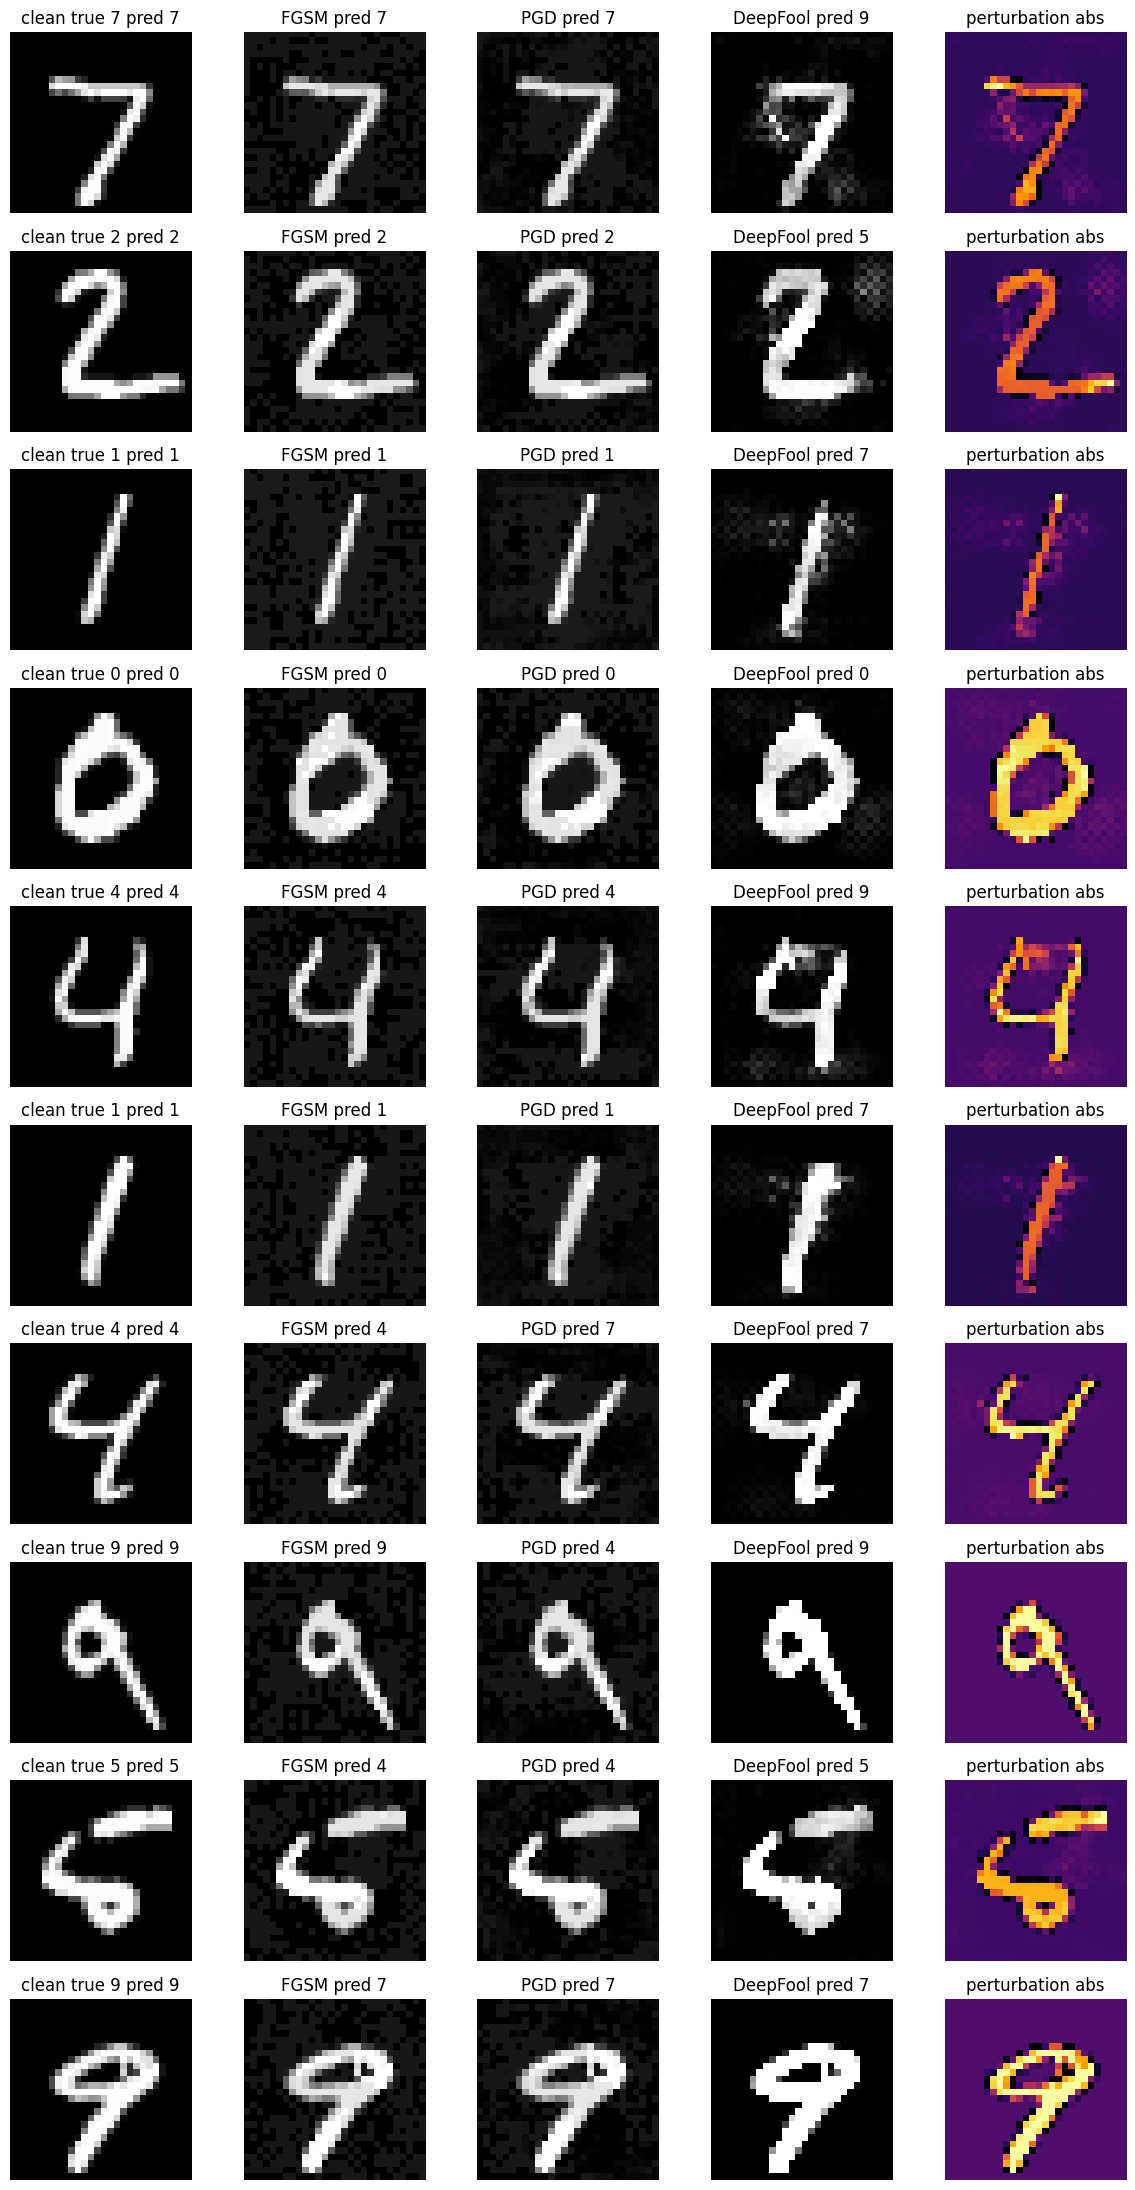

In [35]:
# Visualize multiple adversarial examples (clean vs FGSM vs PGD vs DeepFool vs perturbation)

def show_attack_examples(model, loader, epsilon, alpha, steps, device, n=10):

    model.eval()

    images, labels = next(iter(loader))
    images = images[:n].to(device)
    labels = labels[:n].to(device)

    x_fgsm = fgsm_attack(model, images, labels, epsilon, device)
    x_pgd = pgd_attack(model, images, labels, epsilon, alpha, steps, device)
    x_deepfool = deepfool_attack(model, images, labels, device=device, steps=deepfool_steps, overshoot=deepfool_overshoot)

    with torch.no_grad():
        logits_clean = model(images)
        logits_fgsm = model(x_fgsm)
        logits_pgd = model(x_pgd)
        logits_deepfool = model(x_deepfool)

    preds_clean = logits_clean.argmax(dim=1)
    preds_fgsm = logits_fgsm.argmax(dim=1)
    preds_pgd = logits_pgd.argmax(dim=1)
    preds_deepfool = logits_deepfool.argmax(dim=1)

    images_cpu = images.detach().cpu()
    x_fgsm_cpu = x_fgsm.detach().cpu()
    x_pgd_cpu = x_pgd.detach().cpu()
    x_deepfool_cpu = x_deepfool.detach().cpu()

    fig, axes = plt.subplots(n, 5, figsize=(12, 2.2*n))

    for i in range(n):

        clean = images_cpu[i,0]
        fgsm = x_fgsm_cpu[i,0]
        pgd = x_pgd_cpu[i,0]
        deepfool = x_deepfool_cpu[i,0]

        perturb = (deepfool-clean).abs()

        axes[i,0].imshow(clean, cmap="gray")
        axes[i,0].set_title(f"clean true {labels[i].item()} pred {preds_clean[i].item()}")

        axes[i,1].imshow(fgsm, cmap="gray")
        axes[i,1].set_title(f"FGSM pred {preds_fgsm[i].item()}")

        axes[i,2].imshow(pgd, cmap="gray")
        axes[i,2].set_title(f"PGD pred {preds_pgd[i].item()}")

        axes[i,3].imshow(deepfool, cmap="gray")
        axes[i,3].set_title(f"DeepFool pred {preds_deepfool[i].item()}")

        axes[i,4].imshow(perturb, cmap="inferno")
        axes[i,4].set_title("perturbation abs")

        for j in range(5):
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()


# Show 10 examples
show_attack_examples(
    model,
    testloader,
    epsilon=0.3,
    alpha=0.05,
    steps=10,
    device=device,
    n=10
)

Robustness curve

We evaluate classifier accuracy under attacks across multiple epsilon values and compare the effect of input transformations.

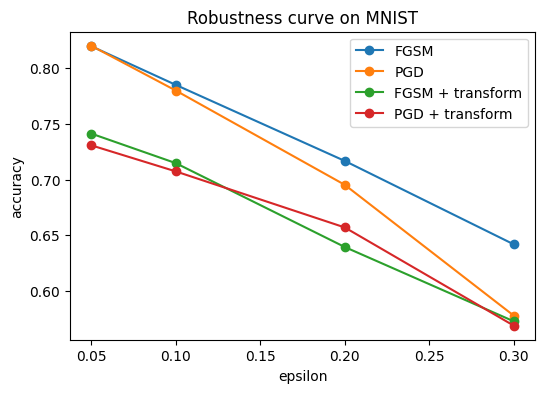

In [36]:
# Robustness curve (accuracy vs epsilon)

eps_list = [0.05, 0.1, 0.2, 0.3]

fgsm_acc_list = []
pgd_acc_list = []
fgsm_transform_acc_list = []
pgd_transform_acc_list = []

alpha = 0.05
steps = 10

for eps in eps_list:
    fgsm_acc_list.append(evaluate_fgsm_accuracy(model, testloader, eps, device, max_batches=10))
    pgd_acc_list.append(evaluate_pgd_accuracy(model, testloader, eps, alpha, steps, device, max_batches=10))
    fgsm_transform_acc_list.append(evaluate_fgsm_accuracy_with_transform(model, testloader, eps, device, max_batches=10))
    pgd_transform_acc_list.append(evaluate_pgd_accuracy_with_transform(model, testloader, eps, alpha, steps, device, max_batches=10))

plt.figure(figsize=(6, 4))
plt.plot(eps_list, fgsm_acc_list, marker="o", label="FGSM")
plt.plot(eps_list, pgd_acc_list, marker="o", label="PGD")
plt.plot(eps_list, fgsm_transform_acc_list, marker="o", label="FGSM + transform")
plt.plot(eps_list, pgd_transform_acc_list, marker="o", label="PGD + transform")
plt.xlabel("epsilon")
plt.ylabel("accuracy")
plt.title("Robustness curve on MNIST")
plt.legend()
plt.show()

### Interpretation of the robustness curve

This plot shows how the model accuracy changes as the attack strength (epsilon) increases.

Several observations can be made.  

First, when epsilon increases, the model accuracy decreases for both FGSM and PGD attacks. This indicates that stronger perturbations make it easier for the attacker to fool the classifier.  

Second, PGD consistently produces lower accuracy than FGSM for the same epsilon values. This confirms that PGD is a stronger attack because it applies multiple optimization steps to craft more effective adversarial examples.  

Third, the input transformation defense does not improve robustness. In fact, the curves for FGSM + transform and PGD + transform are consistently below the original attack curves. This means that the preprocessing step slightly degrades the model performance rather than protecting it.  

Overall, this experiment shows that simple input transformations provide limited protection against adversarial attacks. As the perturbation magnitude increases, the model becomes increasingly vulnerable  

### Why input transformations can reduce accuracy

Input transformations are intended to weaken adversarial perturbations before the image is processed by the classifier. However, they can also remove useful visual information from the original digit.

In this experiment, the transformation pipeline includes operations such as resizing, smoothing, or small spatial changes. While these operations may reduce part of the adversarial noise, they also blur or distort the input. As a result, the classifier may lose important features needed for correct recognition.

This explains why the transformed accuracy can sometimes be lower than the original adversarial accuracy. This behavior is not a bug. It shows that simple preprocessing defenses may trade off robustness and image quality, and do not guarantee better performance against adversarial attacks.

### Step 10: Export report and artifacts

In [37]:
import os
import json
import pandas as pd

report_dir = "reports_02f"
os.makedirs(report_dir, exist_ok=True)

results_export = {
    "baseline_accuracy": float(baseline_accuracy),
    "fgsm_accuracy": float(results["FGSM"]["accuracy"]),
    "pgd_accuracy": float(results["PGD"]["accuracy"]),
    "deepfool_accuracy": float(results["DeepFool"]["accuracy"]),
    "fgsm_transform_accuracy": float(fgsm_transform_before),
    "pgd_transform_accuracy": float(pgd_transform_before),
    "deepfool_transform_accuracy": float(deepfool_transform_before),
    "detector_tpr_fgsm": float(results["FGSM"]["tpr"]),
    "detector_tpr_pgd": float(results["PGD"]["tpr"]),
    "detector_tpr_deepfool": float(results["DeepFool"]["tpr"]),
    "tau": float(tau)
}

json_path = os.path.join(report_dir, "final_results.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results_export, f, indent=4)

df_results.to_csv(os.path.join(report_dir, "final_results_table.csv"), index=False)

print("Saved:", json_path)
print("Saved:", os.path.join(report_dir, "final_results_table.csv"))
print(json.dumps(results_export, indent=4))

Saved: reports_02f\final_results.json
Saved: reports_02f\final_results_table.csv
{
    "baseline_accuracy": 0.8781,
    "fgsm_accuracy": 0.641796875,
    "pgd_accuracy": 0.577734375,
    "deepfool_accuracy": 0.404296875,
    "fgsm_transform_accuracy": 0.58203125,
    "pgd_transform_accuracy": 0.56875,
    "deepfool_transform_accuracy": 0.3828125,
    "detector_tpr_fgsm": 0.084765625,
    "detector_tpr_pgd": 0.090625,
    "detector_tpr_deepfool": 0.84921875,
    "tau": 0.401891827583313
}


### Takeaways



In [ ]:
##########################################################################################################################################
#  results: baseline, FGSM, PGD, DeepFool, detector TPR and input transformation robustness are all summarized in the final table above  #
##########################################################################################################################################

A classifier can achieve high accuracy on clean data while still being highly vulnerable to small adversarial perturbations.

Different attacks affect the model differently. In our experiments, PGD and DeepFool reduce accuracy more than FGSM, highlighting the importance of evaluating multiple attacks.

Simple preprocessing defenses such as input transformations provide limited protection and may even slightly degrade model performance.

A confidence based detector can identify some adversarial examples. However, its effectiveness strongly depends on the attack type. In our case, the detector performs well against DeepFool but struggles to detect FGSM and PGD attacks.